<a href="https://colab.research.google.com/github/Anthea05/PCVK26_03_Anthea/blob/main/week3_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Anthea Amodia Syaffah Atthaillah'
NIM  = '244107020024'

N    = int(NIM[-3:])
PARAM = {
    'b'    : (N % 61) + 20,
    'a'    : round(1.0 + (N % 9) / 10, 1),
    'c'    : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print("%-6s :" % k, v)
print('WAKTU  :', waktu.strftime("%Y-%m-%d %H:%M:%S %Z"))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Anthea Amodia Syaffah Atthaillah
NIM  : 244107020024 | N = 24
b      : 44
a      : 1.6
c      : 34
gamma  : 0.4
bit    : 2
WAKTU  : 2026-09-18 07:46:54 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 3ec36cd9f06f29a0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


-------------------------------------------
      Mengubah tingkat kecerahan citra     
-------------------------------------------
Masukkan nilai kecerahan: 50


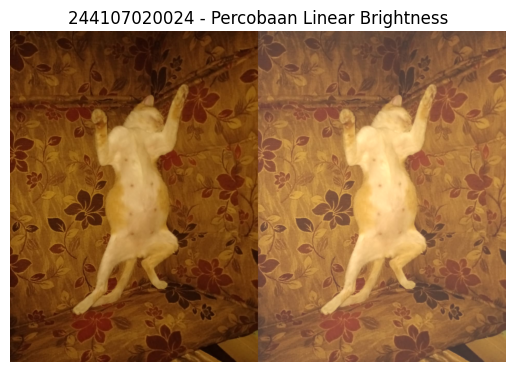

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020024"

print('-------------------------------------------')
print('      Mengubah tingkat kecerahan citra     ')
print('-------------------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    brightness = 0

original = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/OBJ1.jpeg')

brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])

plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Percobaan Linear Brightness")
plt.axis('off')
plt.show()

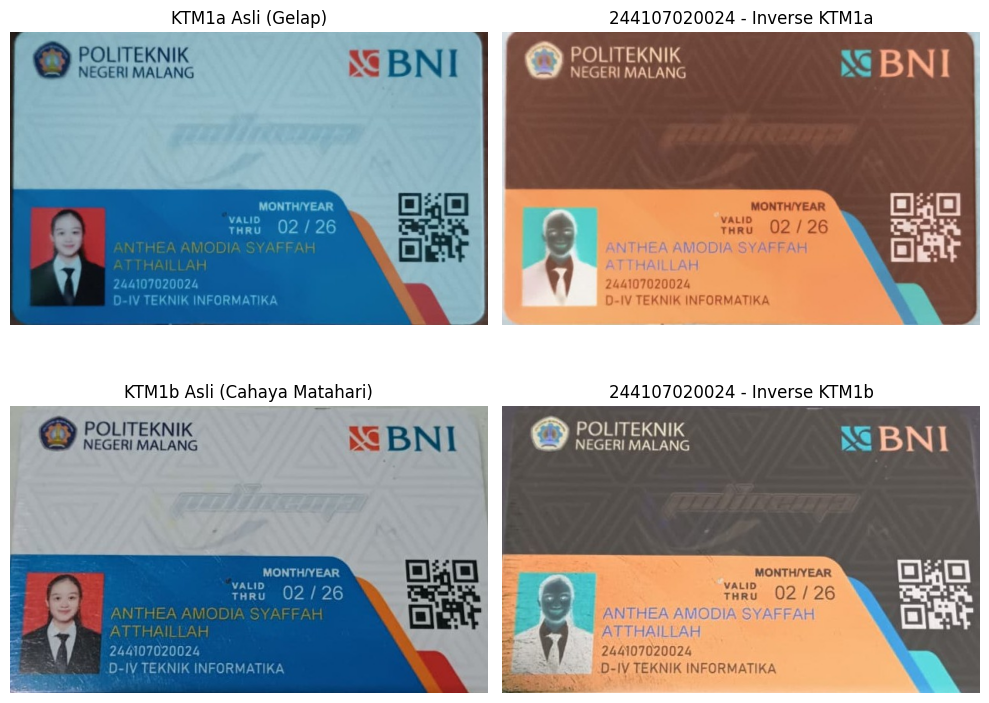

'\nPenjelasan:\nKTM1a diambil di ruangan gelap, jadi intensitasnya rendah mendekati 0 sampai hitam. Ketika di-inverse menggunakan rumus $g(x)=255-f(x)$, nilai-nilai rendah ini dibalik jadi sangat tinggi (mendekati 255 atau putih), jadi secara keseluruhan citra berubah menjadi sangat terang, pucat, sampai kehilangan detailnya.\nSedangkan KTM1b diambil menggunakan cahaya matahari yang cukup, jadi sebaran entang piksel yang gelap dan terang merata. saat diinvers proporsi perbedaan warna tetap merata dan masih terlihat detail seperti gambar aslinya.\n'

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg'
path_ktm1b = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1b.jpeg'

img_ktm1a = cv.imread(path_ktm1a)
img_ktm1b = cv.imread(path_ktm1b)

if img_ktm1a is None or img_ktm1b is None:
    print("Error: Citra tidak ditemukan. Pastikan nama dan lokasi file sesuai.")
else:
    # Konversibyaa
    img_ktm1a = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)
    img_ktm1b = cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB)

    # Operasi Inverse: 255 - nilai piksel asli
    inv_ktm1a = 255 - img_ktm1a
    inv_ktm1b = 255 - img_ktm1b

    # Menyiapkan plot 2 baris, 2 kolom
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

    # Baris 1: KTM1a
    ax[0, 0].imshow(img_ktm1a)
    ax[0, 0].set_title("KTM1a Asli (Gelap)")
    ax[0, 0].axis('off')

    ax[0, 1].imshow(inv_ktm1a)
    ax[0, 1].set_title(f"{NIM} - Inverse KTM1a")
    ax[0, 1].axis('off')

    # Baris 2: KTM1b
    ax[1, 0].imshow(img_ktm1b)
    ax[1, 0].set_title("KTM1b Asli (Cahaya Matahari)")
    ax[1, 0].axis('off')

    ax[1, 1].imshow(inv_ktm1b)
    ax[1, 1].set_title(f"{NIM} - Inverse KTM1b")
    ax[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

'''
Penjelasan:
KTM1a diambil di ruangan gelap, jadi intensitasnya rendah mendekati 0 sampai hitam. Ketika di-inverse menggunakan rumus $g(x)=255-f(x)$, nilai-nilai rendah ini dibalik jadi sangat tinggi (mendekati 255 atau putih), jadi secara keseluruhan citra berubah menjadi sangat terang, pucat, sampai kehilangan detailnya.
Sedangkan KTM1b diambil menggunakan cahaya matahari yang cukup, jadi sebaran entang piksel yang gelap dan terang merata. saat diinvers proporsi perbedaan warna tetap merata dan masih terlihat detail seperti gambar aslinya.
'''

-------------------------------------------
 Mengubah kontras dan tingkat kecerahan citra 
-------------------------------------------
Masukkan tingkat kecerahan (b): 20
Masukkan kontras (a)  : 1.6


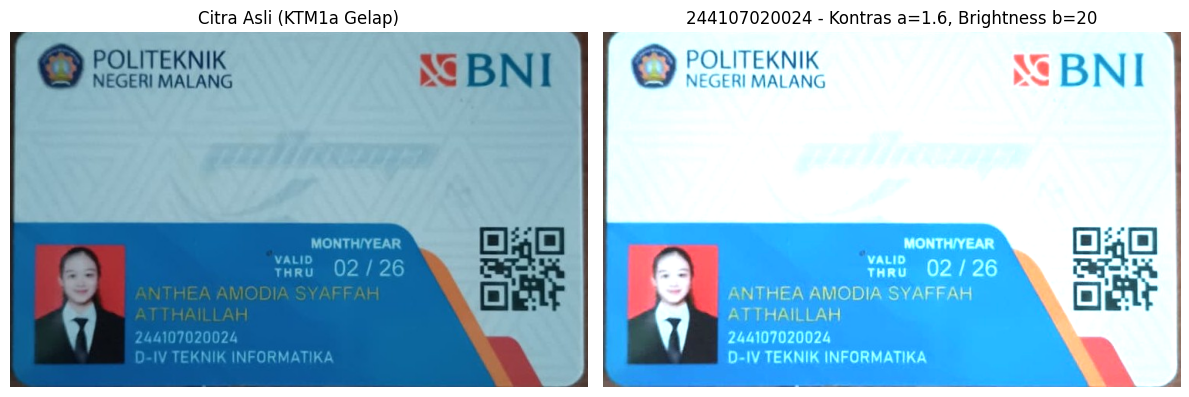

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Asumsi Anda telah menjalankan Sel Identitas sebelumnya
# NIM = "244107020024", maka N = 24
N = int(NIM[-3:])
a = round(1.0 + (N % 9) / 10, 1)

print('-------------------------------------------')
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('-------------------------------------------')

try:
    b = int(input('Masukkan tingkat kecerahan (b): '))
except ValueError:
    print('Error, not a number, defaulting to 10')
    b = 10

print(f"Masukkan kontras (a)  : {a}")

path_ktm1a = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg'
img_ktm1a = cv.imread(path_ktm1a)

if img_ktm1a is not None:
    img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

    # Fungsi cv.convertScaleAbs mengimplementasikan g(x,y) = a*f(x,y) + b
    # alpha merepresentasikan 'a' (kontras) dan beta merepresentasikan 'b' (brightness)
    # Fungsi ini juga secara otomatis menangani truncate/saturasi agar tidak error di luar 0-255
    contrast_img = cv.convertScaleAbs(img_ktm1a_rgb, alpha=a, beta=b)

    # Menampilkan hasil
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(img_ktm1a_rgb)
    ax[0].set_title("Citra Asli (KTM1a Gelap)")
    ax[0].axis('off')

    ax[1].imshow(contrast_img)
    ax[1].set_title(f"{NIM} - Kontras a={a}, Brightness b={b}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Citra KTM1a.jpeg tidak ditemukan!")

Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan: 30


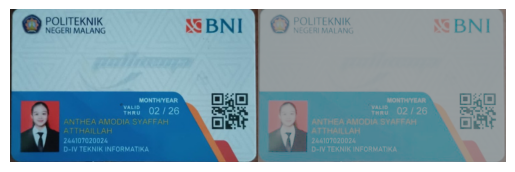

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')
try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

img_ktm1a = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg')

if img_ktm1a is not None:
    img_ktm1a_rgb = cv.cvtColor(img_ktm1a, cv.COLOR_BGR2RGB)

    img_float = img_ktm1a_rgb.astype(np.float32)
    log_img = c * np.log(1 + img_float)

    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    final_frame = cv.hconcat([img_ktm1a_rgb, log_img])

    plt.imshow(final_frame)
    plt.axis('off')
    plt.show()
else:
    print("Citra tidak ditemukan.")

    '''
    penjelasan:
    metode clipping: Pada transformasi linier, nilai brightness ditambahkan secara merata ke setiap piksel sehingga beberapa piksel bisa melebihi batas 255. Akibatnya, area tersebut menjadi putih penuh dan kehilangan detail. Sedangkan transformasi logaritma lebih mengurangi clipping karena peningkatan kecerahannya lebih bertahap.
    '''

a. Averaging


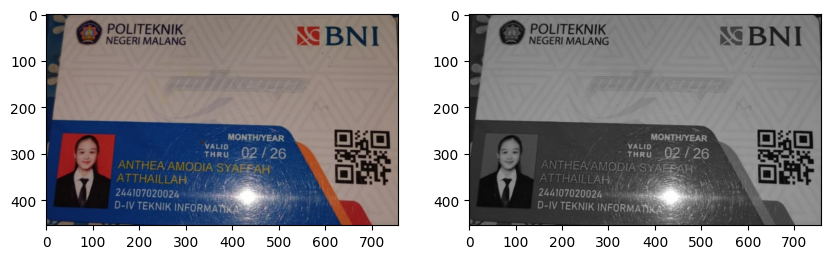

b. Lightness


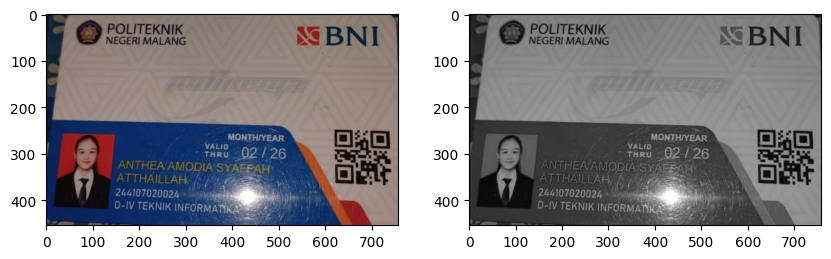

c. Luminance


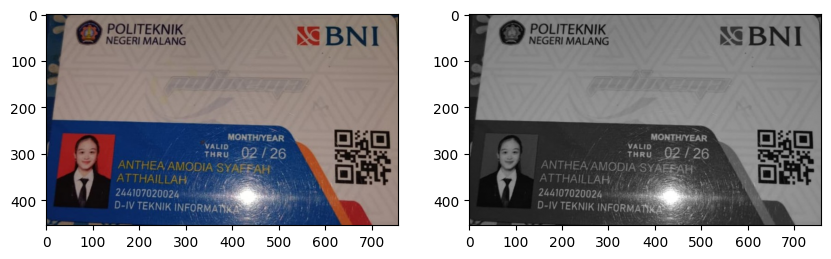


---------------------------------------------------------
Metode          | Rata-rata       | Simpangan Baku 
---------------------------------------------------------
Averaging       | 104.43          | 42.31          
Lightness       | 106.77          | 41.51          
Luminance       | 101.32          | 45.53          
---------------------------------------------------------

Kesimpulan:
Metode Luminance umumnya memberikan pemisahan paling jelas antara teks dan latar
kartu karena bobot warnanya (terutama hijau) disesuaikan dengan tingkat sensitivitas mata manusia.


In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_ktm1c = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1c.jpeg')

if img_ktm1c is not None:
    img_rgb = cv.cvtColor(img_ktm1c, cv.COLOR_BGR2RGB)

    R = img_rgb[:,:,0].astype(np.float32)
    G = img_rgb[:,:,1].astype(np.float32)
    B = img_rgb[:,:,2].astype(np.float32)

    # 1. Averaging
    avg_gray = np.round((R + G + B) / 3).astype(np.uint8)

    # 2. Lightness
    R_G_B_max = np.max(img_rgb, axis=2).astype(np.float32)
    R_G_B_min = np.min(img_rgb, axis=2).astype(np.float32)
    lightness_gray = np.round((R_G_B_max + R_G_B_min) / 2).astype(np.uint8)

    # 3. Luminance
    lum_gray = np.round(0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    # a. Averaging Plot
    print("a. Averaging")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(avg_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # b. Lightness Plot
    print("b. Lightness")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(lightness_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # c. Luminance Plot
    print("c. Luminance")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(img_rgb)
    ax[1].imshow(lum_gray, cmap='gray', vmin=0, vmax=255)
    plt.show()

    # Tabel Rata-rata dan Simpangan Baku
    print("\n---------------------------------------------------------")
    print(f"{'Metode':<15} | {'Rata-rata':<15} | {'Simpangan Baku':<15}")
    print("---------------------------------------------------------")
    print(f"{'Averaging':<15} | {np.mean(avg_gray):<15.2f} | {np.std(avg_gray):<15.2f}")
    print(f"{'Lightness':<15} | {np.mean(lightness_gray):<15.2f} | {np.std(lightness_gray):<15.2f}")
    print(f"{'Luminance':<15} | {np.mean(lum_gray):<15.2f} | {np.std(lum_gray):<15.2f}")
    print("---------------------------------------------------------")

    print("\nKesimpulan:")
    print("Metode Luminance umumnya memberikan pemisahan paling jelas antara teks dan latar")
    print("kartu karena bobot warnanya (terutama hijau) disesuaikan dengan tingkat sensitivitas mata manusia.")
else:
    print("Citra tidak ditemukan.")

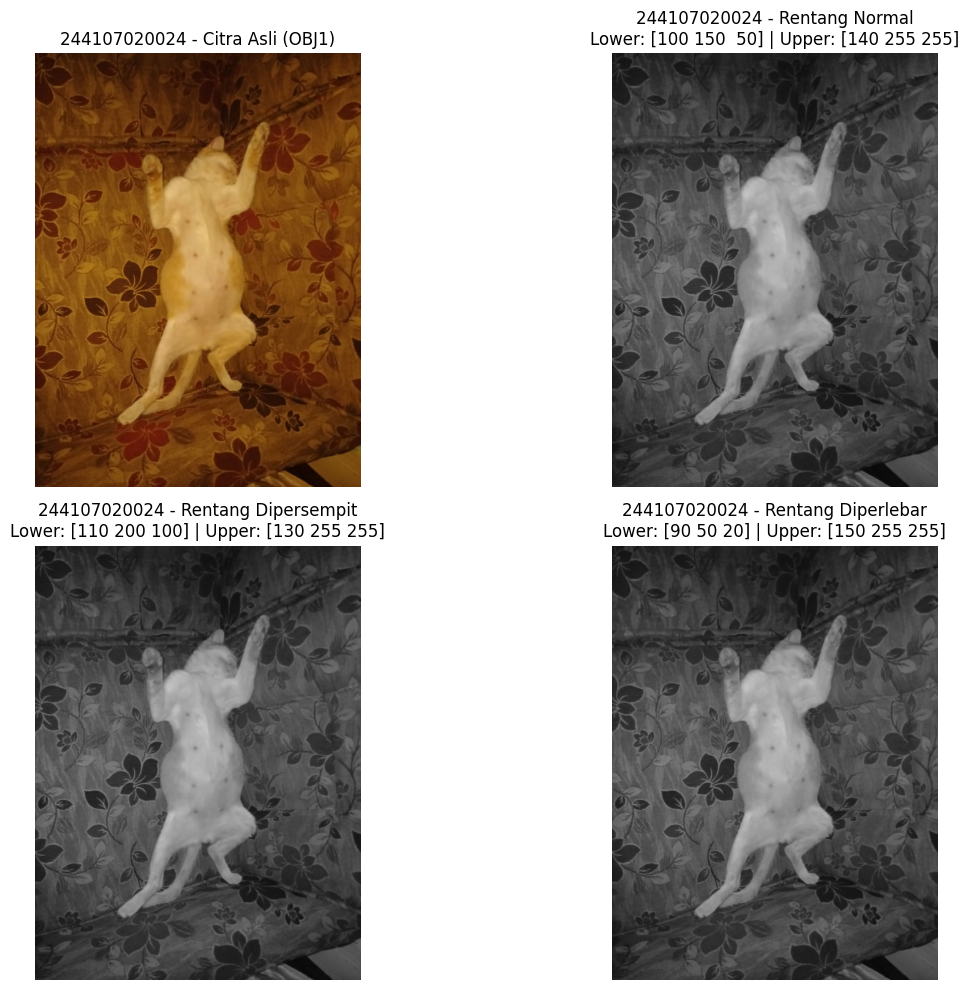


=== Analisa Pengaruh Rentang HSV ===
1. Rentang Dipersempit : Hanya piksel dengan warna yang sangat spesifik yang dipertahankan. Jika terlalu sempit, gradasi warna pada benda (misal akibat bayangan atau pantulan cahaya) tidak akan terdeteksi dan ikut menjadi abu-abu (bolong-bolong).
2. Rentang Diperlebar  : Benda utama akan berhasil dipertahankan warnanya secara utuh. Namun, rentang yang terlalu lebar berisiko menangkap warna latar belakang atau benda lain yang warnanya berdekatan, sehingga bagian yang seharusnya abu-abu malah ikut berwarna.


In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020024"

# Load citra OBJ1.jpeg
img_obj = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/OBJ1.jpeg')

if img_obj is not None:

    img_rgb = cv.cvtColor(img_obj, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

    img_gray = cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY)
    img_gray_3ch = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)

    # 1. Rentang Normal
    lower_normal = np.array([100, 150, 50])
    upper_normal = np.array([140, 255, 255])

    # 2. Rentang Dipersempit (Range H, S, V dikurangi agar lebih ketat)
    lower_sempit = np.array([110, 200, 100])
    upper_sempit = np.array([130, 255, 255])

    # 3. Rentang Diperlebar (Range H, S, V dilonggarkan)
    lower_lebar = np.array([90, 50, 20])
    upper_lebar = np.array([150, 255, 255])

    def apply_color_mask(hsv_img, rgb_img, gray_img, lower, upper):
        # Buat mask biner (Putih untuk warna yang dicari, Hitam untuk sisanya)
        mask = cv.inRange(hsv_img, lower, upper)
        # Terapkan mask: ambil warna asli jika mask putih (255), sisanya grayscale
        result = np.where(mask[:, :, None] == 255, rgb_img, gray_img)
        return result

    res_normal = apply_color_mask(img_hsv, img_rgb, img_gray_3ch, lower_normal, upper_normal)
    res_sempit = apply_color_mask(img_hsv, img_rgb, img_gray_3ch, lower_sempit, upper_sempit)
    res_lebar = apply_color_mask(img_hsv, img_rgb, img_gray_3ch, lower_lebar, upper_lebar)

    # Menampilkan perbandingan 4 gambar sekaligus
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))

    ax[0, 0].imshow(img_rgb)
    ax[0, 0].set_title(f"{NIM} - Citra Asli (OBJ1)")
    ax[0, 0].axis('off')

    ax[0, 1].imshow(res_normal)
    ax[0, 1].set_title(f"{NIM} - Rentang Normal\nLower: {lower_normal} | Upper: {upper_normal}")
    ax[0, 1].axis('off')

    ax[1, 0].imshow(res_sempit)
    ax[1, 0].set_title(f"{NIM} - Rentang Dipersempit\nLower: {lower_sempit} | Upper: {upper_sempit}")
    ax[1, 0].axis('off')

    ax[1, 1].imshow(res_lebar)
    ax[1, 1].set_title(f"{NIM} - Rentang Diperlebar\nLower: {lower_lebar} | Upper: {upper_lebar}")
    ax[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n=== Analisa Pengaruh Rentang HSV ===")
    print("1. Rentang Dipersempit : Hanya piksel dengan warna yang sangat spesifik yang dipertahankan. Jika terlalu sempit, gradasi warna pada benda (misal akibat bayangan atau pantulan cahaya) tidak akan terdeteksi dan ikut menjadi abu-abu (bolong-bolong).")
    print("2. Rentang Diperlebar  : Benda utama akan berhasil dipertahankan warnanya secara utuh. Namun, rentang yang terlalu lebar berisiko menangkap warna latar belakang atau benda lain yang warnanya berdekatan, sehingga bagian yang seharusnya abu-abu malah ikut berwarna.")

else:
    print("Citra OBJ1.jpeg tidak ditemukan. Pastikan path file benar.")

 Gamma Correction pada citra 
-------------------------------------------
Masukkan nilai Gamma: 0.5


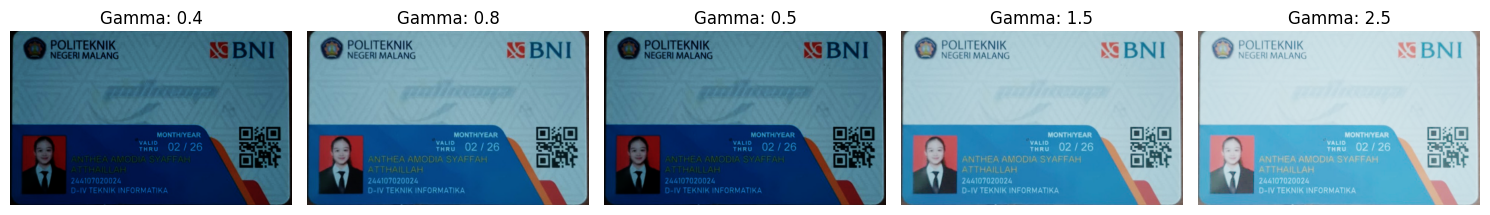

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('-------------------------------------------')
try:
    # Di modul pakai int, tapi diganti float supaya bisa input desimal
    gamma_input = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma_input = 1.0

# Load gambar KTM1a (ruangan gelap)
img = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1a.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Bikin list 5 nilai gamma untuk dibandingkan (termasuk nilai inputan)
gamma_list = [0.4, 0.8, gamma_input, 1.5, 2.5]

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    g = gamma_list[i]

    # Rumus: I' = 255 * (I/255)^(1/gamma)
    img_gamma = 255 * (img_rgb / 255.0) ** (1 / g)
    img_gamma = np.clip(img_gamma, 0, 255).astype(np.uint8)

    ax[i].imshow(img_gamma)
    ax[i].set_title(f'Gamma: {g}')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

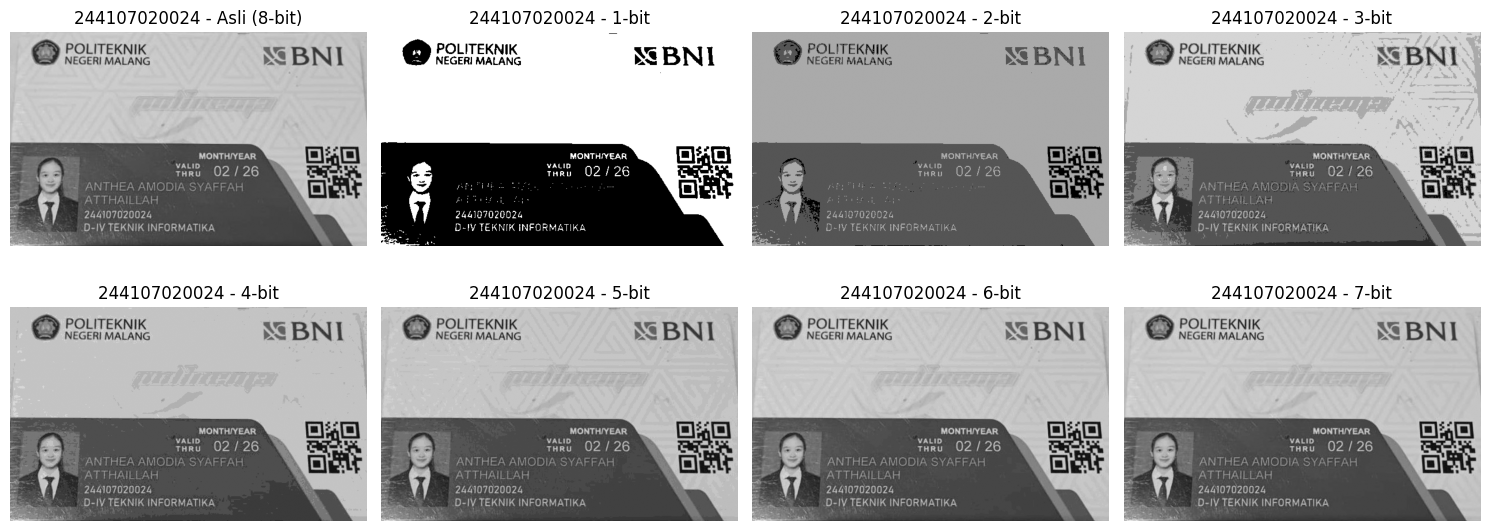

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020024"
img_path = '/content/drive/MyDrive/pcvk_3/images/244107020024/KTM1b.jpeg'
original = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if original is not None:
    fig, ax = plt.subplots(2, 4, figsize=(15, 6))

    ax[0, 0].imshow(original, cmap='gray')
    ax[0, 0].set_title(f'{NIM} - Asli (8-bit)')
    ax[0, 0].axis('off')

    for i in range(1, 8):
        bit_depth = i
        level = 255 / (pow(2, bit_depth) - 1)

        depth_image = np.round(original / level) * level
        depth_image = depth_image.astype(np.uint8)

        row = i // 4
        col = i % 4

        ax[row, col].imshow(depth_image, cmap='gray')
        ax[row, col].set_title(f'{NIM} - {bit_depth}-bit')
        ax[row, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Citra tidak ditemukan!")

No | Jumlah Citra | Nilai PSNR (dB)
-----------------------------------
 1 |           10 | 19.73
 2 |           20 | 19.84
 3 |           40 | 19.89
 4 |           80 | 19.92
 5 |          100 | 19.92


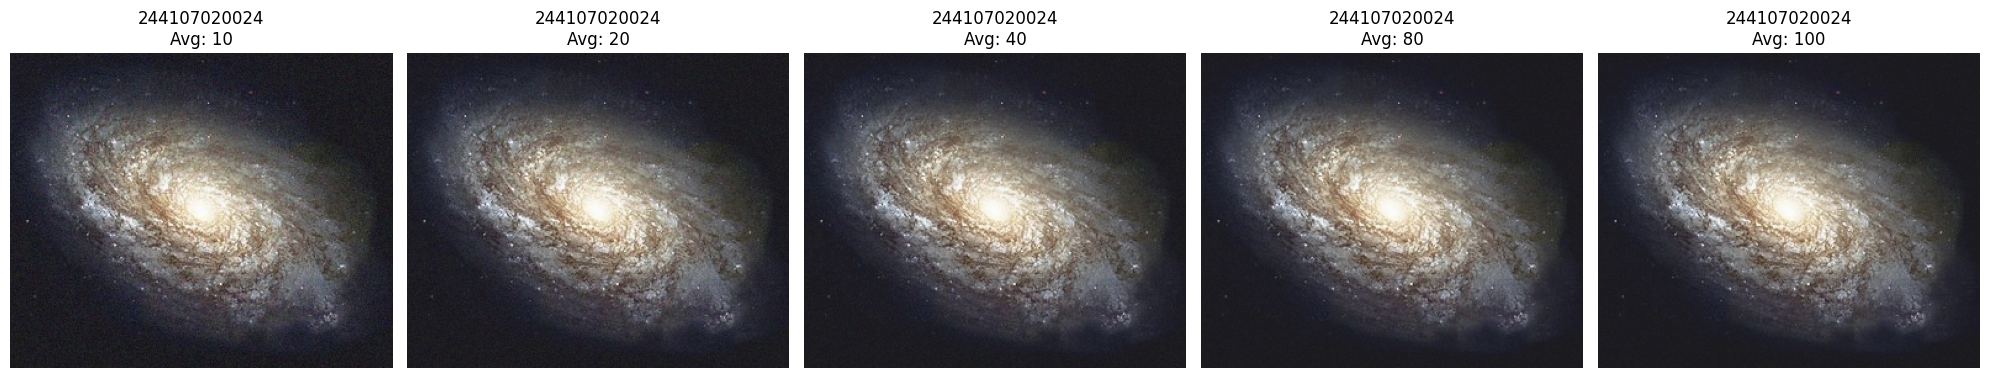

In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math

NIM = "244107020024"

# Fungsi PSNR sesuai modul
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

# Jalur file yang sudah diperbarui sesuai lokasimu
path_galaxy = '/content/drive/MyDrive/pcvk_3/images/244107020024/galaxy.jpg'
path_noises = '/content/drive/MyDrive/pcvk_3/images/244107020024/noises/noises/*.jpg'

# Load gambar asli
img_asli = cv.imread(path_galaxy)

# Load semua gambar noise
cv_img = []
for img in glob.glob(path_noises):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

# Pastikan gambar berhasil diload
if img_asli is not None and len(cv_img) >= 100:
    jumlah_avg = [10, 20, 40, 80, 100]
    fig, ax = plt.subplots(1, 5, figsize=(20, 4))

    print("No | Jumlah Citra | Nilai PSNR (dB)")
    print("-----------------------------------")

    for i in range(len(jumlah_avg)):
        n_citra = jumlah_avg[i]

        # Bikin variabel penampung float64 agar tidak error saat dijumlahkan
        temp = np.zeros(img_asli.shape, dtype=np.float64)

        # Proses penjumlahan citra
        for j in range(n_citra):
            temp += cv_img[j]

        # Proses rata-rata dan kembalikan ke uint8
        hasil_avg = (temp / n_citra).astype(np.uint8)

        # Hitung PSNR
        nilai_psnr = PSNR(img_asli, hasil_avg)
        print(f"{i+1:2d} | {n_citra:12d} | {nilai_psnr:.2f}")

        # Tampilkan gambar
        hasil_rgb = cv.cvtColor(hasil_avg, cv.COLOR_BGR2RGB)
        ax[i].imshow(hasil_rgb)
        ax[i].set_title(f"{NIM}\nAvg: {n_citra}")
        ax[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Gambar berhasil diload: {len(cv_img)}")
    print("Gambar asli atau folder noises tidak ditemukan! Cek kembali path-nya.")

Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak selalu. Di awal, penambahan citra cukup meningkatkan PSNR, tetapi semakin banyak citra yang digunakan, peningkatannya semakin kecil.
Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Mulai kurang signifikan saat jumlah citra di atas 40. Kenaikan PSNR dari 80 ke 100 citra jauh lebih kecil dibandingkan dari 10 ke 20 citra.
Apa kesimpulan dari percobaan ini?
Metode average denoising cukup efektif untuk mengurangi noise. Semakin banyak citra yang dirata-rata, kualitas gambar semakin baik. Namun, setelah sekitar 40 citra, peningkatannya mulai kecil sementara waktu komputasi semakin bertambah.

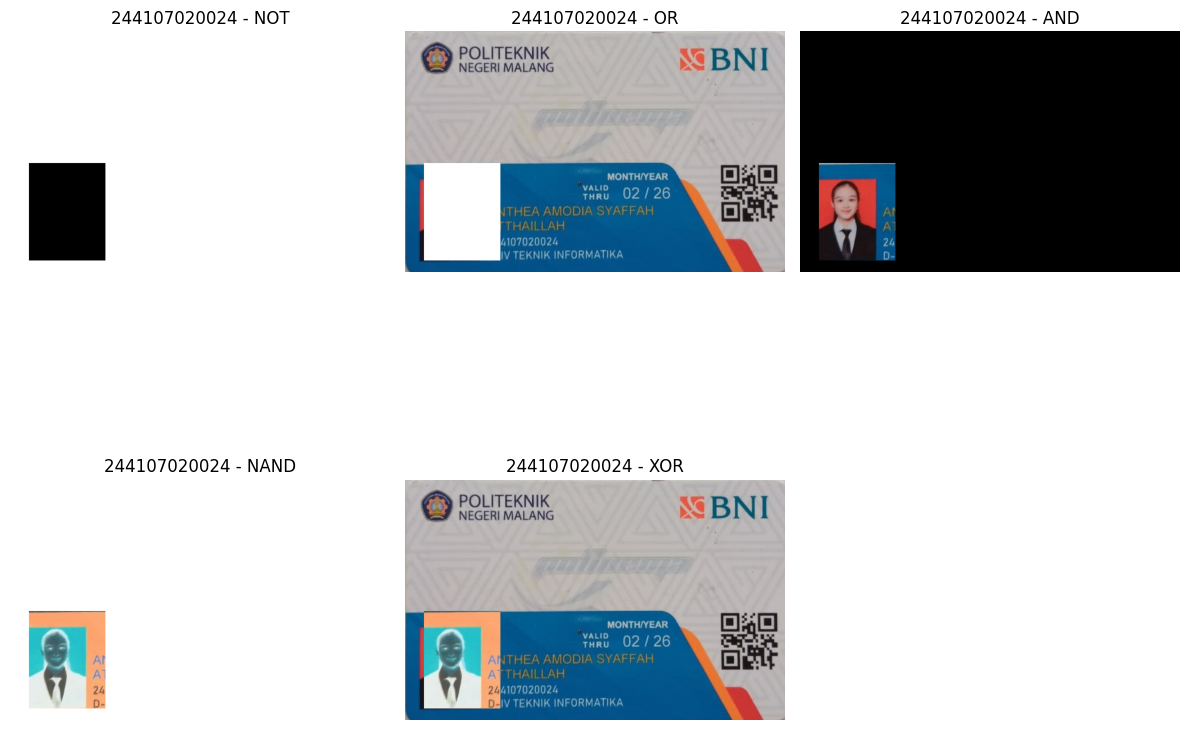

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/pcvk_3/images/244107020024'
img = cv.imread(BASE + '/KTM1d.jpeg')

if img is None:
    raise FileNotFoundError("Gambar KTM1d.jpeg tidak ditemukan!")

h, w = img.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)
cv.rectangle(mask, (int(w*0.05), int(h*0.55)), (int(w*0.25), int(h*0.95)), 255, -1)
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

res_not = cv.bitwise_not(mask_3ch)
res_or = cv.bitwise_or(img, mask_3ch)
res_and = cv.bitwise_and(img, mask_3ch)
res_nand = cv.bitwise_not(res_and)
res_xor = cv.bitwise_xor(img, mask_3ch)

outputs = [res_not, res_or, res_and, res_nand, res_xor]
titles = [f"{NIM} - NOT", f"{NIM} - OR", f"{NIM} - AND", f"{NIM} - NAND", f"{NIM} - XOR"]

plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(cv.cvtColor(outputs[i], cv.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

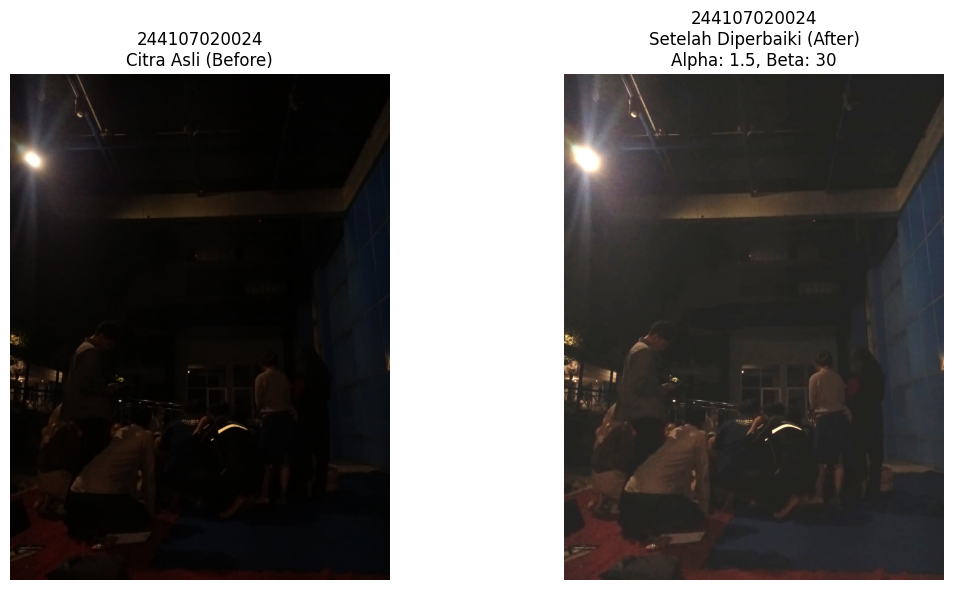

In [38]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020024"

# Ganti path sesuai dengan lokasi foto malam hari milikmu (NIGHT1.jpeg)
img_night = cv.imread('/content/drive/MyDrive/pcvk_3/images/244107020024/NIGHT1.jpeg')

if img_night is not None:
    img_rgb = cv.cvtColor(img_night, cv.COLOR_BGR2RGB)

    # Menentukan parameter (Silakan diubah-ubah sesuai kondisi foto aslimu)
    alpha = 1.5  # Kontras (di atas 1.0 untuk menaikkan kontras)
    beta = 30    # Brightness (ditambah untuk mencerahkan)

    # Menerapkan Linear Contrast & Brightness
    img_corrected = cv.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

    # Menampilkan Before - After
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(img_rgb)
    ax[0].set_title(f"{NIM}\nCitra Asli (Before)")
    ax[0].axis('off')

    ax[1].imshow(img_corrected)
    ax[1].set_title(f"{NIM}\nSetelah Diperbaiki (After)\nAlpha: {alpha}, Beta: {beta}")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Citra NIGHT1.jpeg tidak ditemukan!")

Analisis Perbaikan Kontras dan Brightness
Metode yang dipilih: Saya menggunakan transformasi kontras yang digabungkan dengan Linear Brightness.
Alasan pemilihan: Foto malam biasanya terlihat gelap dan kurang jelas karena banyak piksel memiliki nilai yang rendah. Kontras digunakan untuk memperjelas perbedaan antara objek dan background, sedangkan brightness digunakan untuk membuat bagian yang gelap menjadi lebih terlihat.
Parameter terbaik: Dari beberapa percobaan, nilai alpha 1.5 dan beta 30 memberikan hasil yang cukup baik. Nilai tersebut membuat gambar lebih terang dan detailnya lebih terlihat tanpa membuat gambar terlalu putih.
Hasil Before-After: Setelah dilakukan transformasi, gambar terlihat lebih terang dan objek seperti tulisan NIM menjadi lebih jelas dibandingkan gambar aslinya.